<a href="https://colab.research.google.com/github/hypro2/hands-on-LLM-from-colab/blob/main/turboquant_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/tonbistudio/turboquant-pytorch.git

Cloning into 'turboquant-pytorch'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 24 (delta 5), reused 12 (delta 4), pack-reused 4 (from 1)
Receiving objects: 100% (24/24), 38.09 KiB | 9.52 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [2]:
!pip install -q torch --index-url https://download.pytorch.org/whl/cu128

In [3]:
!cd /content/turboquant-pytorch && pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.3 MB/s eta 0:00:00


In [5]:
!mv turboquant-pytorch turboquant_pytorch

In [6]:
import sys
sys.path.insert(0, '/content')

# TurboQuant 핵심 알고리즘 사용 예시 (synthetic validation)
from turboquant_pytorch.turboquant import TurboQuantMSE, TurboQuantProd
import torch

# 벡터 생성 (KV 캐시 시뮬레이션)
d = 128  # 차원
n = 1000  # 벡터 수
vectors = torch.randn(n, d)

# 3비트 양자화 설정
tq = TurboQuantProd(bits=3, d=d)

# 압축 및 복원
compressed = tq.quantize(vectors)
reconstructed = tq.dequantize(compressed)
print(compressed)
print(reconstructed)


# 내적 정확도 확인 (어텐션 계산용)
query = torch.randn(1, d)
true_attn = query @ vectors.T
approx_attn = tq.inner_product(query, compressed)
print(approx_attn)

{'mse_indices': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 3, 0,  ..., 3, 0, 0],
        [2, 2, 0,  ..., 0, 3, 0],
        ...,
        [0, 0, 0,  ..., 1, 0, 3],
        [0, 0, 3,  ..., 3, 0, 0],
        [0, 0, 3,  ..., 0, 1, 0]]), 'qjl_signs': tensor([[ 1., -1., -1.,  ...,  1.,  1.,  1.],
        [ 1.,  1., -1.,  ..., -1., -1.,  1.],
        [ 1., -1.,  1.,  ...,  1.,  1., -1.],
        ...,
        [ 1., -1.,  1.,  ...,  1., -1.,  1.],
        [ 1., -1., -1.,  ...,  1.,  1.,  1.],
        [ 1., -1., -1.,  ...,  1., -1.,  1.]]), 'residual_norm': tensor([ 9.6337, 10.9192,  9.1602, 11.2034,  9.2334, 10.9949, 10.5177,  8.7514,
        10.2241,  9.6554,  8.8234, 10.4693,  9.7059,  9.7764, 10.3338, 10.1914,
         9.4824,  9.7565,  9.7728,  9.6535, 10.5302,  9.7661, 10.2882, 10.6772,
         9.5494, 10.5793,  9.3758, 10.2059,  9.2536,  8.8225, 10.2730, 10.0036,
         9.1813, 10.7058,  8.9307,  9.9557, 10.0355, 10.2263, 11.1187, 10.3528,
        10.1014, 10.9250, 10.6419, 10.9494, 

In [7]:
"""
TurboQuant 구현을 위한 검증 스크립트입니다.
논문에서 제시된 이론적 예측치와 비교하여 MSE 왜곡 경계, 내적 정확도 및 압축률을 테스트합니다.
"""

import torch
import math
import time
import os
import sys

# TurboQuant 라이브러리에서 핵심 구성 요소 로드
from turboquant_pytorch.turboquant import TurboQuantMSE, TurboQuantProd, TurboQuantKVCache, LloydMaxCodebook


def test_lloyd_max_codebook():
    """
    다양한 차원(Dimension)과 비트 수(Bit-width)에 따른 코드북의 특성을 검증합니다.
    """
    print("=" * 60)
    print("TEST 1: Lloyd-Max Codebook Properties")
    print("=" * 60)

    for d in [64, 128, 256]:
        for bits in [1, 2, 3, 4]:
            # Lloyd-Max 알고리즘 기반 코드북 생성
            cb = LloydMaxCodebook(d, bits)
            print(f"  d={d:>4d}, bits={bits}: {cb.n_levels} levels, "
                  f"distortion/coord={cb.distortion:.6f}, "
                  f"centroids range=[{cb.centroids.min():.4f}, {cb.centroids.max():.4f}]")

    # 대칭성 확인: 센트로이드(Centroids) 값의 합은 0에 수렴해야 함 (대칭적 분포 확인)
    cb = LloydMaxCodebook(128, 3)
    centroid_sum = cb.centroids.sum().abs().item()
    print(f"\n  Symmetry check (d=128, b=3): sum of centroids = {centroid_sum:.6f} (should be ~0)")
    assert centroid_sum < 0.01, "Centroids should be symmetric!"
    print("  PASSED\n")


def test_mse_quantizer():
    """
    무작위 유닛 벡터를 대상으로 MSE(Mean Squared Error) 왜곡 정도를 검증합니다.
    """
    print("=" * 60)
    print("TEST 2: MSE Quantizer Distortion")
    print("=" * 60)

    d = 128
    n_vectors = 1000
    device = "cpu"

    for bits in [1, 2, 3, 4]:
        # MSE 최적화 양자화기 초기화
        quantizer = TurboQuantMSE(d, bits, seed=42, device=device)

        # 무작위 유닛 벡터 생성 및 정규화
        x = torch.randn(n_vectors, d, device=device)
        x = x / torch.norm(x, dim=-1, keepdim=True)

        # 양자화 및 복원(Reconstruction) 수행
        x_hat, indices = quantizer(x)

        # 실제 측정된 MSE 계산
        mse = ((x - x_hat) ** 2).sum(dim=-1).mean().item()

        # 논문에 제시된 이론적 상한선 계산: D_mse <= sqrt(3)*pi/2 * (1/4^b)
        theoretical_bound = math.sqrt(3) * math.pi / 2 * (1 / (4 ** bits))

        ratio = mse / theoretical_bound
        # 유한한 차원(d)을 고려하여 이론치 대비 1.5배 이내면 통과로 간주
        status = "OK" if ratio <= 1.5 else "WARN"

        print(f"  bits={bits}: MSE={mse:.6f}, theory_bound={theoretical_bound:.6f}, "
              f"ratio={ratio:.3f} [{status}]")

    print()


def test_inner_product_unbiasedness():
    """
    TurboQuantProd가 내적(Inner Product) 추정치에서 편향되지 않은(Unbiased) 결과를 제공하는지 검증합니다.
    QJL(Quantized Johnson-Lindenstrauss) 보정 로직의 핵심 테스트입니다.
    """
    print("=" * 60)
    print("TEST 3: Inner Product Unbiasedness (QJL Correction)")
    print("=" * 60)

    d = 128
    n_trials = 2000
    device = "cpu"

    for bits in [2, 3, 4]:
        # 내적 보존형 양자화기 초기화
        quantizer = TurboQuantProd(d, bits, seed=42, device=device)

        # 무작위 유닛 벡터 쌍 생성
        x = torch.randn(n_trials, d, device=device)
        x = x / torch.norm(x, dim=-1, keepdim=True)
        y = torch.randn(n_trials, d, device=device)
        y = y / torch.norm(y, dim=-1, keepdim=True)

        # 실제 내적값 계산
        true_ip = (x * y).sum(dim=-1)

        # x를 양자화한 후, y와의 내적 추정치 계산
        compressed = quantizer.quantize(x)
        estimated_ip = quantizer.inner_product(y, compressed)

        # 편향(Bias) 확인: 0에 가까울수록 이상적
        bias = (estimated_ip - true_ip).mean().item()
        # RMSE 및 상관계수(Correlation) 측정
        rmse = ((estimated_ip - true_ip) ** 2).mean().sqrt().item()
        correlation = torch.corrcoef(torch.stack([true_ip, estimated_ip]))[0, 1].item()

        # 이론적 왜곡 경계: D_prod <= sqrt(3)*pi^2/d * (1/4^b)
        theoretical_distortion = math.sqrt(3) * math.pi ** 2 / d * (1 / (4 ** bits))

        print(f"  bits={bits}: bias={bias:+.6f}, RMSE={rmse:.6f}, "
              f"corr={correlation:.4f}, theory_D={theoretical_distortion:.6f}")

    print()


def test_mse_only_inner_product_bias():
    """
    일반 MSE 양자화기가 내적 계산 시 편향(Bias)을 유발함을 보여줍니다.
    이는 QJL 보정의 필요성을 입증하기 위한 대조군 테스트입니다.
    """
    print("=" * 60)
    print("TEST 4: MSE-Only Inner Product Bias (motivation for QJL)")
    print("=" * 60)

    d = 128
    n_trials = 2000
    device = "cpu"

    for bits in [1, 2, 3]:
        quantizer = TurboQuantMSE(d, bits, seed=42, device=device)

        x = torch.randn(n_trials, d, device=device)
        x = x / torch.norm(x, dim=-1, keepdim=True)
        y = torch.randn(n_trials, d, device=device)
        y = y / torch.norm(y, dim=-1, keepdim=True)

        true_ip = (x * y).sum(dim=-1)
        x_hat, _ = quantizer(x)
        mse_ip = (x_hat * y).sum(dim=-1)

        bias = (mse_ip - true_ip).mean().item()
        # 1-bit 양자화의 경우 약 2/pi (0.637)의 스케일 팩터가 발생함
        scale_factor = (mse_ip.mean() / true_ip.mean()).item() if true_ip.mean().abs() > 0.01 else float('nan')

        print(f"  bits={bits}: bias={bias:+.6f} (MSE-only is biased, QJL fixes this)")

    print()


def test_kv_cache():
    """
    실제 KV 캐시 래퍼를 사용하여 메모리 압축률과 어텐션 스코어 계산을 테스트합니다.
    """
    print("=" * 60)
    print("TEST 5: KV Cache Compression Ratios")
    print("=" * 60)

    d_key = 128
    d_value = 128
    seq_len = 1024
    device = "cpu"

    for bits in [2, 3, 4]:
        # TurboQuant 기반 KV 캐시 생성
        cache = TurboQuantKVCache(d_key, d_value, bits=bits, seed=42, device=device)

        # 시퀀스 데이터 추가 시뮬레이션
        keys = torch.randn(seq_len, d_key, device=device)
        values = torch.randn(seq_len, d_value, device=device)

        cache.append(keys, values)

        # FP16 대비 메모리 사용량 및 압축률 출력
        usage = cache.memory_usage_bits()
        print(f"  bits={bits}: compression={usage['compression_ratio']:.2f}x "
              f"({usage['total_bits'] / 8 / 1024:.1f} KB vs "
              f"{usage['fp16_bits'] / 8 / 1024:.1f} KB fp16)")

        # 양자화된 상태에서의 어텐션 스코어(Attention Scores) 계산 확인
        query = torch.randn(1, d_key, device=device)
        scores = cache.attention_scores(query)
        print(f"           attention scores shape: {scores.shape}, "
              f"range=[{scores.min():.3f}, {scores.max():.3f}]")

    print()


def test_needle_in_haystack():
    """
    단순화된 '건들이 속 바늘 찾기' 테스트:
    특정 키를 수많은 데이터 사이에 숨긴 후 양자화된 상태에서 정확히 검색(Top-k)할 수 있는지 확인합니다.
    """
    print("=" * 60)
    print("TEST 6: Needle-in-Haystack Retrieval")
    print("=" * 60)

    d = 128
    device = "cpu"

    for bits in [2, 3, 4]:
        for seq_len in [512, 2048, 8192]:
            keys = torch.randn(seq_len, d, device=device)
            keys = keys / torch.norm(keys, dim=-1, keepdim=True)

            # 임의의 '바늘(Needle)' 위치 선정 및 쿼리 생성 (Exact Match 환경)
            needle_pos = seq_len // 3
            query = keys[needle_pos].clone().unsqueeze(0)

            # TurboQuant를 사용한 전체 키 양자화
            quantizer = TurboQuantProd(d, bits, seed=42, device=device)
            compressed = quantizer.quantize(keys)

            # 양자화된 내적 계산을 통한 키 검색
            estimated_ips = quantizer.inner_product(
                query.expand(seq_len, -1), compressed
            )

            # 결과 순위 확인
            top_idx = estimated_ips.argmax().item()
            found = top_idx == needle_pos
            top5 = estimated_ips.topk(5).indices.tolist()
            in_top5 = needle_pos in top5

            status = "EXACT" if found else ("TOP-5" if in_top5 else "MISS")
            print(f"  bits={bits}, seq={seq_len:>5d}: top1={top_idx:>5d} "
                  f"(needle={needle_pos:>5d}) [{status}]")

    print()


def test_gpu_if_available():
    """
    CUDA 사용 가능 시 GPU 벤치마크를 수행합니다.
    양자화 시간, 내적 연산 시간 및 FP16과의 메모리 차이를 비교합니다.
    """
    print("=" * 60)
    print("TEST 7: GPU Benchmark (if CUDA available)")
    print("=" * 60)

    if not torch.cuda.is_available():
        print("  CUDA not available, skipping GPU test")
        print()
        return

    device = "cuda"
    d = 128
    bits = 3
    seq_len = 8192
    n_queries = 64

    print(f"  GPU: {torch.cuda.get_device_name()}")
    print(f"  Config: d={d}, bits={bits}, seq_len={seq_len}, n_queries={n_queries}")

    quantizer = TurboQuantProd(d, bits, seed=42, device=device)

    # 벤치마크용 데이터 생성
    keys = torch.randn(seq_len, d, device=device)
    keys = keys / torch.norm(keys, dim=-1, keepdim=True)
    queries = torch.randn(n_queries, d, device=device)
    queries = queries / torch.norm(queries, dim=-1, keepdim=True)

    # 1. 양자화 성능 측정
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(10):
        compressed = quantizer.quantize(keys)
    torch.cuda.synchronize()
    quant_time = (time.perf_counter() - t0) / 10
    print(f"  Quantize {seq_len} keys: {quant_time * 1000:.2f} ms")

    # 2. 양자화 내적 성능 측정
    compressed = quantizer.quantize(keys)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(100):
        for i in range(n_queries):
            ip = quantizer.inner_product(queries[i:i+1].expand(seq_len, -1), compressed)
    torch.cuda.synchronize()
    ip_time = (time.perf_counter() - t0) / 100
    print(f"  Inner product ({n_queries} queries x {seq_len} keys): {ip_time * 1000:.2f} ms")

    # 3. 전체 정밀도(Full-precision) Matmul과 속도 비교
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(100):
        fp_scores = queries @ keys.T
    torch.cuda.synchronize()
    fp_time = (time.perf_counter() - t0) / 100
    print(f"  Full-precision matmul: {fp_time * 1000:.2f} ms")

    # 4. 메모리 절감 수치 요약
    fp16_bytes = seq_len * d * 2
    quant_bytes = seq_len * d * bits / 8
    print(f"  Memory: {fp16_bytes / 1024:.1f} KB (fp16) vs {quant_bytes / 1024:.1f} KB (TQ-{bits}bit)")
    print(f"  Compression: {fp16_bytes / quant_bytes:.1f}x")
    print()


if __name__ == "__main__":
    print()
    print("TurboQuant Implementation Verification")
    print("Based on: 'TurboQuant: Online Vector Quantization' (ICLR 2026)")
    print()

    # 테스트 스위트 실행
    test_lloyd_max_codebook()
    test_mse_quantizer()
    test_inner_product_unbiasedness()
    test_mse_only_inner_product_bias()
    test_kv_cache()
    test_needle_in_haystack()
    test_gpu_if_available()

    print("=" * 60)
    print("ALL TESTS COMPLETE")
    print("=" * 60)


TurboQuant Implementation Verification
Based on: 'TurboQuant: Online Vector Quantization' (ICLR 2026)

TEST 1: Lloyd-Max Codebook Properties
  d=  64, bits=1: 2 levels, distortion/coord=0.005678, centroids range=[-0.0997, 0.0997]
  d=  64, bits=2: 4 levels, distortion/coord=0.001836, centroids range=[-0.1888, 0.1888]
  d=  64, bits=3: 8 levels, distortion/coord=0.000540, centroids range=[-0.2690, 0.2690]
  d=  64, bits=4: 16 levels, distortion/coord=0.000148, centroids range=[-0.3416, 0.3416]
  d= 128, bits=1: 2 levels, distortion/coord=0.002839, centroids range=[-0.0705, 0.0705]
  d= 128, bits=2: 4 levels, distortion/coord=0.000918, centroids range=[-0.1335, 0.1335]
  d= 128, bits=3: 8 levels, distortion/coord=0.000270, centroids range=[-0.1902, 0.1902]
  d= 128, bits=4: 16 levels, distortion/coord=0.000074, centroids range=[-0.2416, 0.2416]
  d= 256, bits=1: 2 levels, distortion/coord=0.001419, centroids range=[-0.0499, 0.0499]
  d= 256, bits=2: 4 levels, distortion/coord=0.000459, 

In [8]:
"""
TurboQuant V3 생성 테스트:
V3로 압축 및 해제된 KV 캐시를 사용하여 모델이 일관된 출력을 생성할 수 있는지 검증합니다.
"""

import torch
import os
import sys
import gc

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DynamicCache

# TurboQuant 라이브러리 경로 추가
sys.path.insert(0, '/content')
from turboquant_pytorch.compressors_v3 import TurboQuantV3

# 테스트용 상수 설정
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
NEEDLE = "The secret project code name is AURORA-7749."  # 찾고자 하는 핵심 정보 (바늘)
EXPECTED = "AURORA-7749"  # 기대하는 정답

# 컨텍스트를 채우기 위한 더미 텍스트 (건더기)
FILLER = """The quarterly financial review meeting covered several topics including..."""


def build_prompt(tokenizer, target_tokens=2048, needle_pos=0.5):
    """
    지정된 토큰 수와 위치(needle_pos)에 맞게 정보 검색용 프롬프트를 생성합니다.
    """
    filler_len = len(tokenizer.encode(FILLER))
    n_reps = max(1, target_tokens // filler_len)
    needle_idx = int(n_reps * needle_pos)

    parts = []
    for i in range(n_reps):
        if i == needle_idx:
            parts.append(f"\n--- Internal Memo ---\n{NEEDLE}\n--- End Memo ---\n\n")
        parts.append(FILLER)

    haystack = "".join(parts)
    # Qwen-2.5의 ChatML 포맷 적용
    return (
        f"<|im_start|>system\nYou are a helpful assistant. Answer concisely.<|im_end|>\n"
        f"<|im_start|>user\nRead this document:\n\n{haystack}\n\n"
        f"What is the secret project code name? Answer with just the code name.<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


class V3Cache(DynamicCache):
    """
    TurboQuant V3를 사용하여 KV 캐시를 압축 저장하는 동적 캐시 클래스입니다.

    특징:
    - 증분형 청크 저장: 매번 전체를 재압축하지 않고 새로 들어온 데이터만 처리합니다.
    - 잔차 윈도우(Residual Window): 가장 최근의 토큰들은 FP16 정밀도로 유지하여 품질 저하를 방지합니다.
    """

    def __init__(self, key_bits=4, value_bits=2, residual_window=128,
                 protected_layers=0, n_layers=36):
        super().__init__()
        self.key_bits = key_bits
        self.value_bits = value_bits
        self.residual_window = residual_window  # FP16으로 유지할 토큰 창 크기
        self.protected_layers = protected_layers # 양자화하지 않고 보호할 레이어 수
        self.n_layers = n_layers

        self._compressors = {}   # 레이어별 TurboQuantV3 인스턴스
        self._chunks_k = {}      # 압축된 Key 청크 리스트
        self._chunks_v = {}      # 압축된 Value 청크 리스트
        self._fp16_recent_k = {} # 최근 Key 상태 (FP16)
        self._fp16_recent_v = {} # 최근 Value 상태 (FP16)
        self._total_seq = {}     # 레이어별 누적 시퀀스 길이

    def _get_compressor(self, layer_idx, head_dim, device):
        """레이어별 압축기(Compressor) 인스턴스를 지연 로딩(Lazy Loading)합니다."""
        if layer_idx not in self._compressors:
            self._compressors[layer_idx] = TurboQuantV3(
                head_dim=head_dim,
                key_bits=self.key_bits,
                value_bits=self.value_bits,
                residual_window=0,  # 윈도우 관리는 이 클래스에서 직접 수행
                layer_idx=layer_idx,
                n_layers=self.n_layers,
                protected_layers=self.protected_layers,
                seed=42,
                device=str(device),
            )
        return self._compressors[layer_idx]

    def update(self, key_states, value_states, layer_idx, cache_kwargs=None):
        """
        새로운 KV 상태를 캐시에 업데이트합니다.
        잔차 윈도우를 넘어서는 데이터는 즉시 압축되어 청크로 저장됩니다.
        """
        B, H, S_new, D = key_states.shape
        device = key_states.device
        comp = self._get_compressor(layer_idx, D, device)

        # 초기화 로직
        if layer_idx not in self._chunks_k:
            self._chunks_k[layer_idx], self._chunks_v[layer_idx] = [], []
            self._fp16_recent_k[layer_idx], self._fp16_recent_v[layer_idx] = [], []
            self._total_seq[layer_idx] = 0

        self._total_seq[layer_idx] += S_new

        # 1. 최근 FP16 버퍼에 새로운 토큰 추가
        self._fp16_recent_k[layer_idx].append(key_states)
        self._fp16_recent_v[layer_idx].append(value_states)

        recent_k = torch.cat(self._fp16_recent_k[layer_idx], dim=2)
        recent_v = torch.cat(self._fp16_recent_v[layer_idx], dim=2)
        rw = self.residual_window

        # 2. 윈도우 크기를 초과한 데이터(Overflow)를 압축하여 청크 저장소로 이동
        if recent_k.shape[2] > rw and rw > 0:
            overflow = recent_k.shape[2] - rw
            to_compress_k = recent_k[:, :, :overflow, :]
            to_compress_v = recent_v[:, :, :overflow, :]

            # TurboQuant V3 압축 수행
            ck, cv = comp.compress_kv(to_compress_k, to_compress_v)
            self._chunks_k[layer_idx].append(ck)
            self._chunks_v[layer_idx].append(cv)

            # 버퍼에는 최근 윈도우만큼의 데이터만 유지
            recent_k = recent_k[:, :, overflow:, :]
            recent_v = recent_v[:, :, overflow:, :]
            self._fp16_recent_k[layer_idx] = [recent_k]
            self._fp16_recent_v[layer_idx] = [recent_v]

        # 3. 어텐션 연산을 위해 전체 KV 복원 (압축 청크들 해제 + 최근 FP16 데이터 결합)
        parts_k, parts_v = [], []
        for ck, cv in zip(self._chunks_k[layer_idx], self._chunks_v[layer_idx]):
            dk, dv = comp.decompress_kv(ck, cv)
            parts_k.append(dk.to(key_states.dtype))
            parts_v.append(dv.to(value_states.dtype))

        parts_k.append(torch.cat(self._fp16_recent_k[layer_idx], dim=2))
        parts_v.append(torch.cat(self._fp16_recent_v[layer_idx], dim=2))

        full_k = torch.cat(parts_k, dim=2)
        full_v = torch.cat(parts_v, dim=2)

        # DynamicLayer 호환성 유지
        while len(self.layers) <= layer_idx:
            from transformers.cache_utils import DynamicLayer
            self.layers.append(DynamicLayer())

        return full_k, full_v

    def get_seq_length(self, layer_idx=0):
        return self._total_seq.get(layer_idx, 0)


def run_test(model, tokenizer, target_tokens, config, needle_pos=0.5):
    """설정된 파라미터에 따라 모델 추론을 실행하고 '바늘' 검색 여부를 판단합니다."""
    prompt = build_prompt(tokenizer, target_tokens, needle_pos)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=target_tokens + 512)
    input_ids = inputs["input_ids"].to("cuda")
    attention_mask = inputs["attention_mask"].to("cuda")

    label = config.get("label", "???")
    print(f"  [{label}] {input_ids.shape[1]} tokens, needle@{needle_pos:.0%}...", end=" ", flush=True)

    # 캐시 설정 (FP16 베이스라인 또는 TurboQuant V3)
    if config.get("fp16"):
        cache = None
    else:
        cache = V3Cache(
            key_bits=config["key_bits"],
            value_bits=config["value_bits"],
            residual_window=config.get("residual_window", 128),
            protected_layers=config.get("protected_layers", 0),
            n_layers=model.config.num_hidden_layers,
        )

    gc.collect()
    torch.cuda.empty_cache()

    # 답변 생성
    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=32,
            do_sample=False,
            past_key_values=cache,
            use_cache=True,
        )

    # 결과 디코딩 및 검증
    new_tokens = outputs[0][input_ids.shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    found = EXPECTED.lower() in response.lower()

    safe_print = response[:60].replace("\n", " ")
    print(f"{'FOUND' if found else 'MISS'} | \"{safe_print}\"")
    return found, response


def main():
    """메인 테스트 실행 루프"""
    print("\nLoading model...", flush=True)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    # 4-bit NF4 양자화로 모델 로드 (가중치 압축)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type="nf4"
        ),
        device_map="auto", dtype=torch.float16,
    )
    model.eval()

    # 테스트할 다양한 비트 설정 (Key와 Value에 서로 다른 비트 할당 가능)
    configs = [
        {"fp16": True, "label": "FP16 (baseline)"},
        {"key_bits": 4, "value_bits": 2, "residual_window": 0,   "label": "V3 K4/V2"},
        {"key_bits": 4, "value_bits": 4, "residual_window": 0,   "label": "V3 K4/V4"},
        {"key_bits": 3, "value_bits": 3, "residual_window": 0,   "label": "V3 K3/V3"},
    ]

    # 컨텍스트 길이(2k, 4k, 8k)별로 테스트 수행
    results = {}
    for ctx in [2048, 4096, 8192]:
        print(f"\n  Context: ~{ctx} tokens")
        results[ctx] = {}
        for cfg in configs:
            found, _ = run_test(model, tokenizer, ctx, cfg)
            results[ctx][cfg["label"]] = found

    # 최종 결과 테이블 출력
if __name__ == "__main__":
    main()


Loading model...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


  Context: ~2048 tokens
  [FP16 (baseline)] 2107 tokens, needle@50%... 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


FOUND | "AURORA-7749"
  [V3 K4/V2] 2107 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V4] 2107 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K3/V3] 2107 tokens, needle@50%... FOUND | "AURORA-7749"

  Context: ~4096 tokens
  [FP16 (baseline)] 4157 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V2] 4157 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V4] 4157 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K3/V3] 4157 tokens, needle@50%... FOUND | "AURORA-7749"

  Context: ~8192 tokens
  [FP16 (baseline)] 8257 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V2] 8257 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V4] 8257 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K3/V3] 8257 tokens, needle@50%... FOUND | "AURORA-7749"


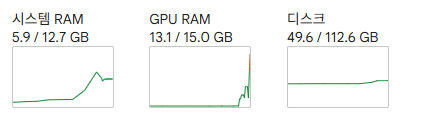